# Tutorial 2 — The Sinkhorn Algorithm

**What you will learn**
- Why exact OT is computationally expensive at scale
- How entropic regularisation makes OT differentiable and fast
- Step-by-step derivation of the Sinkhorn iteration
- How regularisation strength controls the sharpness of the plan
- The Sinkhorn divergence: correcting for bias and recovering a proper distance

**Prerequisites** — Tutorial 1 (optimal transport basics).

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import torch
import torchmatch
from torchmatch.transport.matrix import Backend

plt.rcParams.update({"figure.dpi": 120, "font.size": 11})
rng = np.random.default_rng(0)
print("torchmatch", torchmatch.__version__)

torchmatch 1.0.0


## 1  Why exact OT does not scale

Exact OT is solved by a **network simplex** (a variant of the simplex
method for flow problems).  Its worst-case complexity is
`O((N+M)³ log(N+M))`.

For a histogram comparison with N = M = 1000 bins:
`(2000)³ = 8 × 10⁹` operations per problem — roughly 30 seconds on a CPU
even at 10⁹ operations per second.  For a batch of 64 such problems
(a mini-batch in training), that is over 30 minutes per gradient step.

Exact OT is therefore limited to **small problems** (N, M ≤ a few hundred).
This is why torchmatch exposes it only as `EXACT_EMD` and recommends
Sinkhorn-based backends for everything larger.

In [2]:
# Demonstrate the EXACT_EMD backend on a small problem
N = 32
grid = np.linspace(0, 1, N, dtype=np.float32)
a = np.ones(N, dtype=np.float32) / N
b_shifted = np.ones(N, dtype=np.float32) / N  # same uniform, but we'll compare timing

C_small = ((grid[:, None] - grid[None, :]) ** 2).astype(np.float32)
cost_t = torch.tensor(C_small).unsqueeze(0)
a_t = torch.tensor(a).unsqueeze(0)
b_t = torch.tensor(b_shifted).unsqueeze(0)

plan_exact = torchmatch.transport.matrix.solve(
    cost_t, a=a_t, b=b_t, backend=Backend.EXACT_EMD
)
print("EXACT_EMD output shape:", plan_exact.shape)
print(
    f"Plan is sparse: {(plan_exact.exp() > 1e-6).float().mean():.1%} of entries non-zero"
)

EXACT_EMD output shape: torch.Size([1, 32, 32])
Plan is sparse: 100.0% of entries non-zero


## 2  Entropic regularisation

Cuturi (2013) proposed adding an **entropy term** to the OT objective:

```
OT_ε(a, b, C) = min_{P ∈ U(a,b)} ⟨P, C⟩ − ε · H(P)
```

where `H(P) = −∑_{ij} P_{ij} log P_{ij}` is the entropy of the plan and
`ε > 0` is the regularisation strength.

**Why this helps**:
1. The regularised problem has a **unique** solution.
2. The solution factors as `P_ε = diag(u) · K · diag(v)` where
   `K_{ij} = exp(−C_{ij} / ε)` — just matrix scalings.
3. The solution can be found by the **Sinkhorn iteration** in O(N²) per
   step, using simple row/column normalizations.
4. The plan is **dense** (all entries > 0) and **differentiable** w.r.t.
   the cost matrix — enabling gradient-based training.

## 3  The Sinkhorn iteration step by step

Starting from `K_{ij} = exp(−C_{ij} / ε)`:

Initialise `v = ones(M)`, then repeat until convergence:
```
u ← a / (K @ v)        # rescale rows to match source marginal
v ← b / (Kᵀ @ u)      # rescale columns to match target marginal
```
The plan at convergence is `P = diag(u) @ K @ diag(v)`.

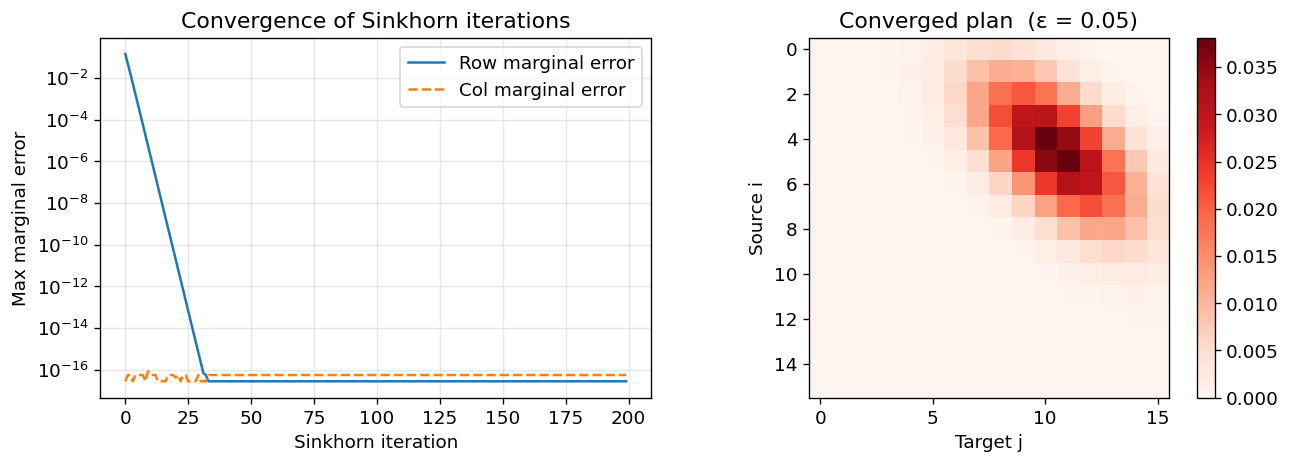

After 200 iterations:
  Max row error: 2.78e-17
  Max col error: 5.55e-17


In [3]:
def sinkhorn_numpy(C, a, b, reg, n_iter=200):
    """Pure NumPy Sinkhorn for illustration."""
    K = np.exp(-C / reg)
    v = np.ones(len(b), dtype=np.float64)

    row_errors, col_errors = [], []
    for _ in range(n_iter):
        u = a / (K @ v + 1e-300)
        v = b / (K.T @ u + 1e-300)
        P_current = np.diag(u) @ K @ np.diag(v)
        row_errors.append(np.abs(P_current.sum(axis=1) - a).max())
        col_errors.append(np.abs(P_current.sum(axis=0) - b).max())

    P = np.diag(u) @ K @ np.diag(v)
    return P, row_errors, col_errors


N = 16
grid_s = np.linspace(0, 1, N, dtype=np.float64)
a_demo = np.exp(-0.5 * ((grid_s - 0.3) / 0.15) ** 2)
b_demo = np.exp(-0.5 * ((grid_s - 0.7) / 0.15) ** 2)
a_demo /= a_demo.sum()
b_demo /= b_demo.sum()
C_demo = ((grid_s[:, None] - grid_s[None, :]) ** 2).astype(np.float64)

P_sink, row_err, col_err = sinkhorn_numpy(C_demo, a_demo, b_demo, reg=0.05)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].semilogy(row_err, label="Row marginal error")
axes[0].semilogy(col_err, label="Col marginal error", ls="--")
axes[0].set_xlabel("Sinkhorn iteration")
axes[0].set_ylabel("Max marginal error")
axes[0].set_title("Convergence of Sinkhorn iterations")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

im = axes[1].imshow(P_sink, cmap="Reds", vmin=0, origin="upper")
axes[1].set_xlabel("Target j")
axes[1].set_ylabel("Source i")
axes[1].set_title(f"Converged plan  (ε = 0.05)")
plt.colorbar(im, ax=axes[1])

plt.tight_layout()
plt.show()

print(f"After {len(row_err)} iterations:")
print(f"  Max row error: {row_err[-1]:.2e}")
print(f"  Max col error: {col_err[-1]:.2e}")

## 4  Effect of the regularisation parameter ε

Small ε → plan approaches exact OT (sparse, high transport cost).
Large ε → plan approaches uniform coupling (mass spreads everywhere).

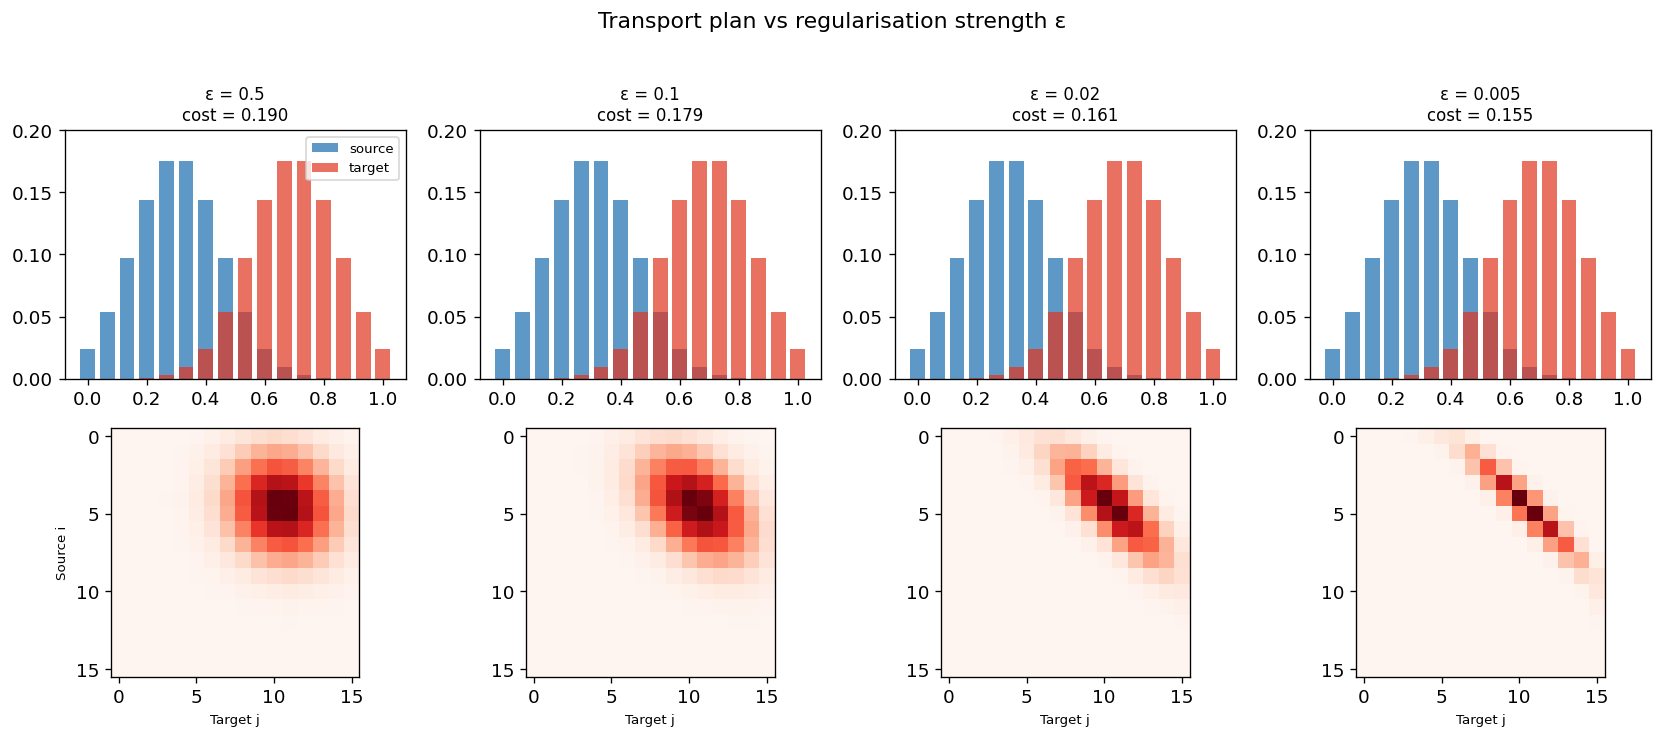

In [4]:
regs = [0.5, 0.1, 0.02, 0.005]
fig, axes = plt.subplots(2, 4, figsize=(14, 6))

for col, reg in enumerate(regs):
    P_r, _, _ = sinkhorn_numpy(C_demo, a_demo, b_demo, reg=reg, n_iter=500)
    cost_r = (P_r * C_demo).sum()

    axes[0, col].bar(
        grid_s, a_demo, color="#1a6daf", alpha=0.7, label="source", width=0.05
    )
    axes[0, col].bar(
        grid_s, b_demo, color="#E03520", alpha=0.7, label="target", width=0.05
    )
    if col == 0:
        axes[0, col].legend(fontsize=8)
    axes[0, col].set_title(f"ε = {reg}\ncost = {cost_r:.3f}", fontsize=10)
    axes[0, col].set_ylim(0, 0.20)

    im = axes[1, col].imshow(P_r, cmap="Reds", vmin=0, origin="upper")
    axes[1, col].set_xlabel("Target j", fontsize=8)
    if col == 0:
        axes[1, col].set_ylabel("Source i", fontsize=8)

plt.suptitle("Transport plan vs regularisation strength ε", y=1.02)
plt.tight_layout()
plt.show()

As ε decreases, the plan becomes more "diagonal" (mass moves to the nearest
matching bin) and approaches the exact OT solution.  torchmatch's
`LOG_SINKHORN` backend works entirely in log space (`f = ε log u`,
`g = ε log v`) to remain numerically stable even at very small ε.

## 5  Log-domain Sinkhorn in torchmatch

All three Sinkhorn backends in torchmatch use the log-domain formulation
for numerical stability.  Let us reproduce the experiment above using the
actual API.

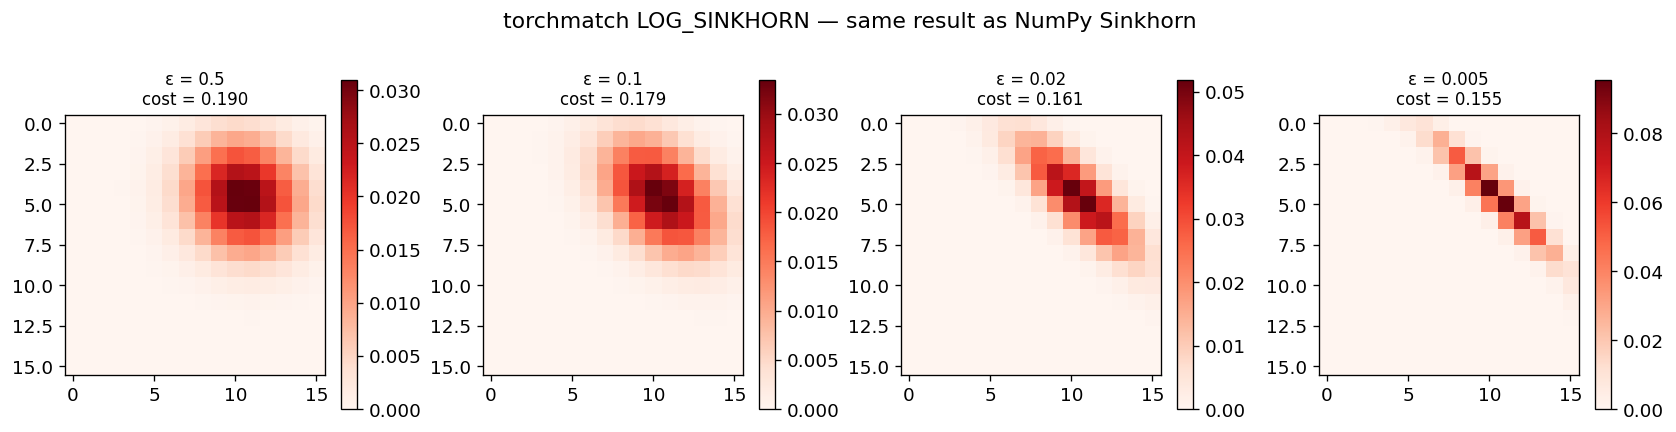

In [5]:
C_t = torch.tensor(C_demo, dtype=torch.float32).unsqueeze(0)
a_t = torch.tensor(a_demo, dtype=torch.float32).unsqueeze(0)
b_t = torch.tensor(b_demo, dtype=torch.float32).unsqueeze(0)

fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
for col, reg in enumerate(regs):
    log_plan = torchmatch.transport.matrix.solve(
        C_t,
        a=a_t,
        b=b_t,
        backend=Backend.LOG_SINKHORN,
        reg=reg,
        n_iter=500,
    )
    P_tm = log_plan.exp().squeeze(0).numpy()
    cost_tm = (P_tm * C_demo).sum()

    im = axes[col].imshow(P_tm, cmap="Reds", vmin=0, origin="upper")
    axes[col].set_title(f"ε = {reg}\ncost = {cost_tm:.3f}", fontsize=10)
    plt.colorbar(im, ax=axes[col])

plt.suptitle("torchmatch LOG_SINKHORN — same result as NumPy Sinkhorn", y=1.02)
plt.tight_layout()
plt.show()

## 6  The Sinkhorn divergence

The raw regularised OT loss `⟨P_ε, C⟩` has two problems:
1. It is **not symmetric**: `OT_ε(a, b) ≠ OT_ε(b, a)` (because the plan differs).
2. It is **not zero at a = b**: entropy regularisation smears mass even
   when source and target already match, so `OT_ε(a, a) > 0`.

The **Sinkhorn divergence** corrects both:

```
SD_ε(a, b) = OT_ε(a, b) − ½ OT_ε(a, a) − ½ OT_ε(b, b)
```

`SD_ε(a, b) ≥ 0` with equality iff `a = b`; it is symmetric and serves as
a proper distance for training.

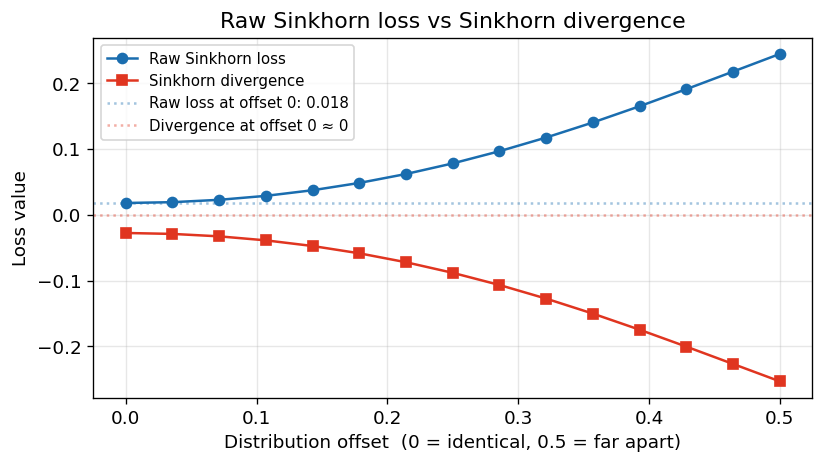

Raw Sinkhorn loss when distributions are identical: 0.0180  (not zero!)
Sinkhorn divergence when distributions are identical: -0.027655  (≈ 0)


In [6]:
# Compare: raw Sinkhorn loss vs Sinkhorn divergence as distributions drift apart
offsets = np.linspace(0, 0.5, 15)
raw_losses = []
divergences = []

for offset in offsets:
    b_shifted = np.exp(-0.5 * ((grid_s - 0.3 - offset) / 0.15) ** 2)
    b_shifted = (b_shifted / b_shifted.sum()).astype(np.float32)
    b_st = torch.tensor(b_shifted).unsqueeze(0)

    raw = torchmatch.transport.matrix.solve(
        C_t, a=a_t, b=b_st, backend=Backend.LOG_SINKHORN, reg=0.05, n_iter=300
    )
    raw_cost = (raw.exp().squeeze(0).numpy() * C_demo).sum()
    raw_losses.append(raw_cost)

    div = torchmatch.transport.matrix.solve(
        C_t, a=a_t, b=b_st, backend=Backend.SINKHORN_DIVERGENCE, reg=0.05, n_iter=300
    )
    divergences.append(div.item())

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(offsets, raw_losses, "o-", label="Raw Sinkhorn loss", color="#1a6daf")
ax.plot(offsets, divergences, "s-", label="Sinkhorn divergence", color="#E03520")
ax.axhline(
    raw_losses[0],
    color="#1a6daf",
    ls=":",
    alpha=0.4,
    label=f"Raw loss at offset 0: {raw_losses[0]:.3f}",
)
ax.axhline(0, color="#E03520", ls=":", alpha=0.4, label="Divergence at offset 0 ≈ 0")
ax.set_xlabel("Distribution offset  (0 = identical, 0.5 = far apart)")
ax.set_ylabel("Loss value")
ax.set_title("Raw Sinkhorn loss vs Sinkhorn divergence")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(
    f"Raw Sinkhorn loss when distributions are identical: {raw_losses[0]:.4f}  (not zero!)"
)
print(
    f"Sinkhorn divergence when distributions are identical: {divergences[0]:.6f}  (≈ 0)"
)

The Sinkhorn divergence starts at 0 when `a = b` and grows as the
distributions drift apart — exactly what a good training loss should do.

## Summary

- **Exact OT** via network simplex is O((N+M)³) — impractical for ML.
- **Entropic regularisation** adds a smoothness penalty, turning OT into
  a differentiable problem solvable by the Sinkhorn iteration in O(N²) per
  step.
- **Regularisation strength ε** controls the sharpness of the plan: large
  ε → smooth (uniform) plan; small ε → approaches exact OT.
- The **Sinkhorn divergence** removes the self-transport bias, giving a
  symmetric loss that is zero when the two distributions match.

**Next**: [Tutorial 3 — Point Clouds and Shapes](03_point_clouds.ipynb)
applies OT to raw point clouds using torchmatch's Triton streaming kernel.